MULTI-LAYER PERCEPTRON FROM SCRATCH
Adapted from original notebook from Vítor Gama Lemos

[kaggle-notebook](https://www.kaggle.com/code/vitorgamalemos/multilayer-perceptron-from-scratch)


In [2]:
import random
import seaborn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# NOVO: Import para dividir os dados e para calcular a acurácia
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.base import BaseEstimator, ClassifierMixin

seaborn.set(style='whitegrid'); seaborn.set_context('talk')
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

from sklearn.datasets import load_iris
iris_data = load_iris()

In [3]:
print(iris_data['DESCR'])

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

Number of samples: 150
Number of features: 4 



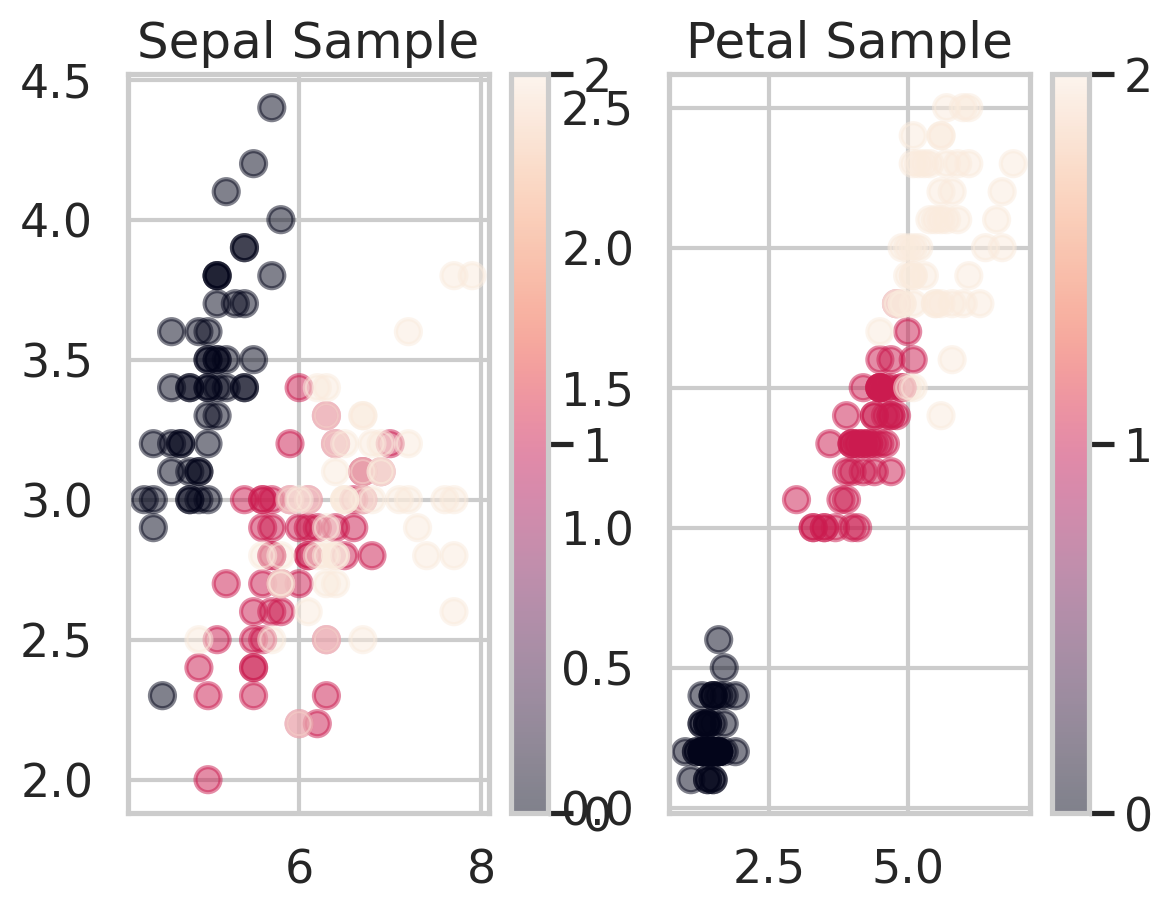

In [4]:
n_samples, n_features = iris_data.data.shape

print(f"Number of samples: {n_samples}")
print(f"Number of features: {n_features} \n")

plt.subplot(1, 2, 1)
scatter_plot = plt.scatter(iris_data.data[:,0], iris_data.data[:,1], alpha=0.5,
                           c=iris_data.target)
plt.colorbar(ticks=([0, 1, 2]))
plt.title('Sepal Sample');

plt.subplot(1, 2, 2)
scatter_plot_2 = plt.scatter(iris_data.data[:,2], iris_data.data[:,3], alpha=0.5,
                           c=iris_data.target)
plt.colorbar(ticks=([0, 1, 2]))
plt.title('Petal Sample');

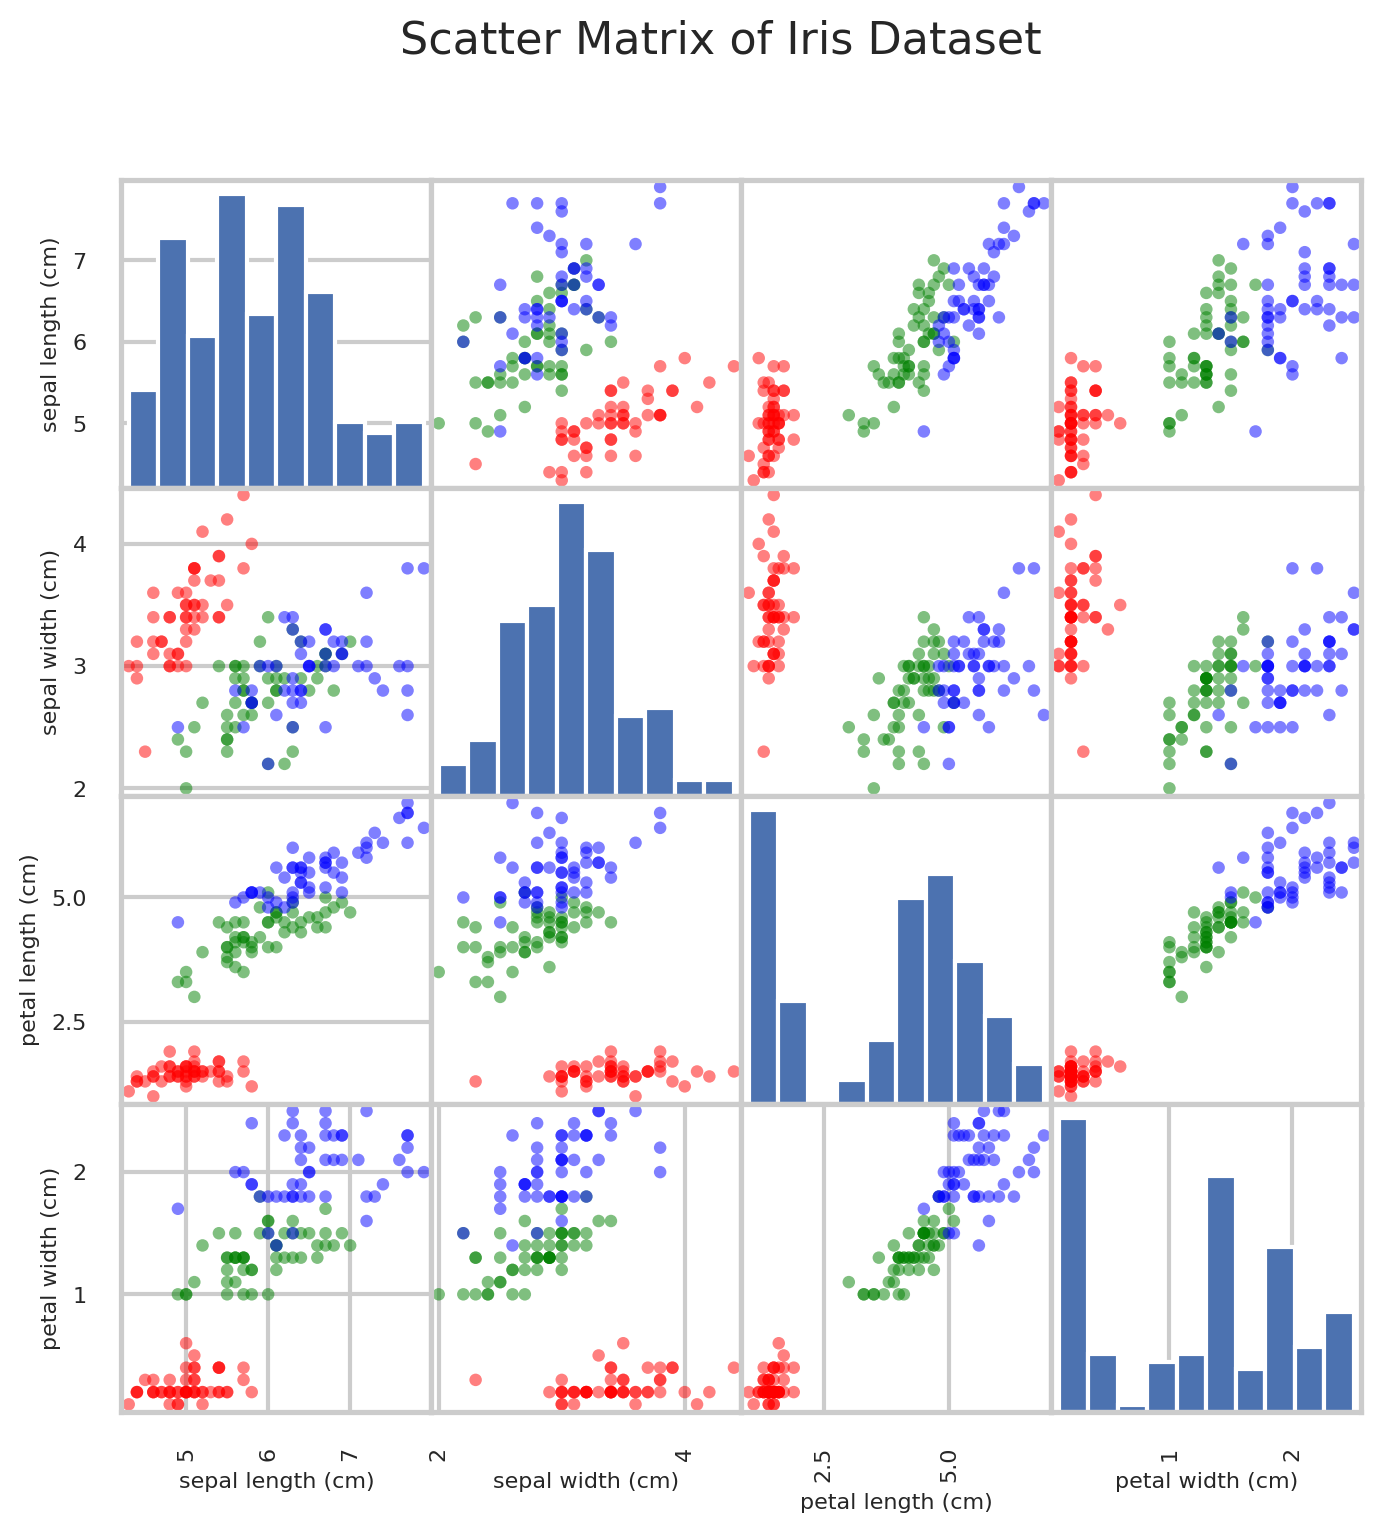

In [5]:
import pandas
from pandas.plotting import scatter_matrix


# Cria um DataFrame com os dados e os nomes das colunas
df = pd.DataFrame(iris_data.data, columns=iris_data.feature_names)
df['target'] = iris_data.target

# Mapeia os números das classes para nomes legíveis
target_names = iris_data.target_names
df['target_name'] = df['target'].apply(lambda i: target_names[i])

# Escolhe uma paleta de cores
colors = {'setosa': 'red', 'versicolor': 'green', 'virginica': 'blue'}
df['color'] = df['target_name'].map(colors)

# Gera o scatter_matrix
axes = scatter_matrix(df[iris_data.feature_names],
               figsize=(8, 8),
               diagonal='hist',
               color=df['color'],
               alpha=0.5)

# Reduz o tamanho da fonte dos rótulos dos eixos
for ax in axes.ravel():
    ax.set_xlabel(ax.get_xlabel(), fontsize=8)
    ax.set_ylabel(ax.get_ylabel(), fontsize=8)

plt.suptitle("Scatter Matrix of Iris Dataset", fontsize=16)
plt.show()

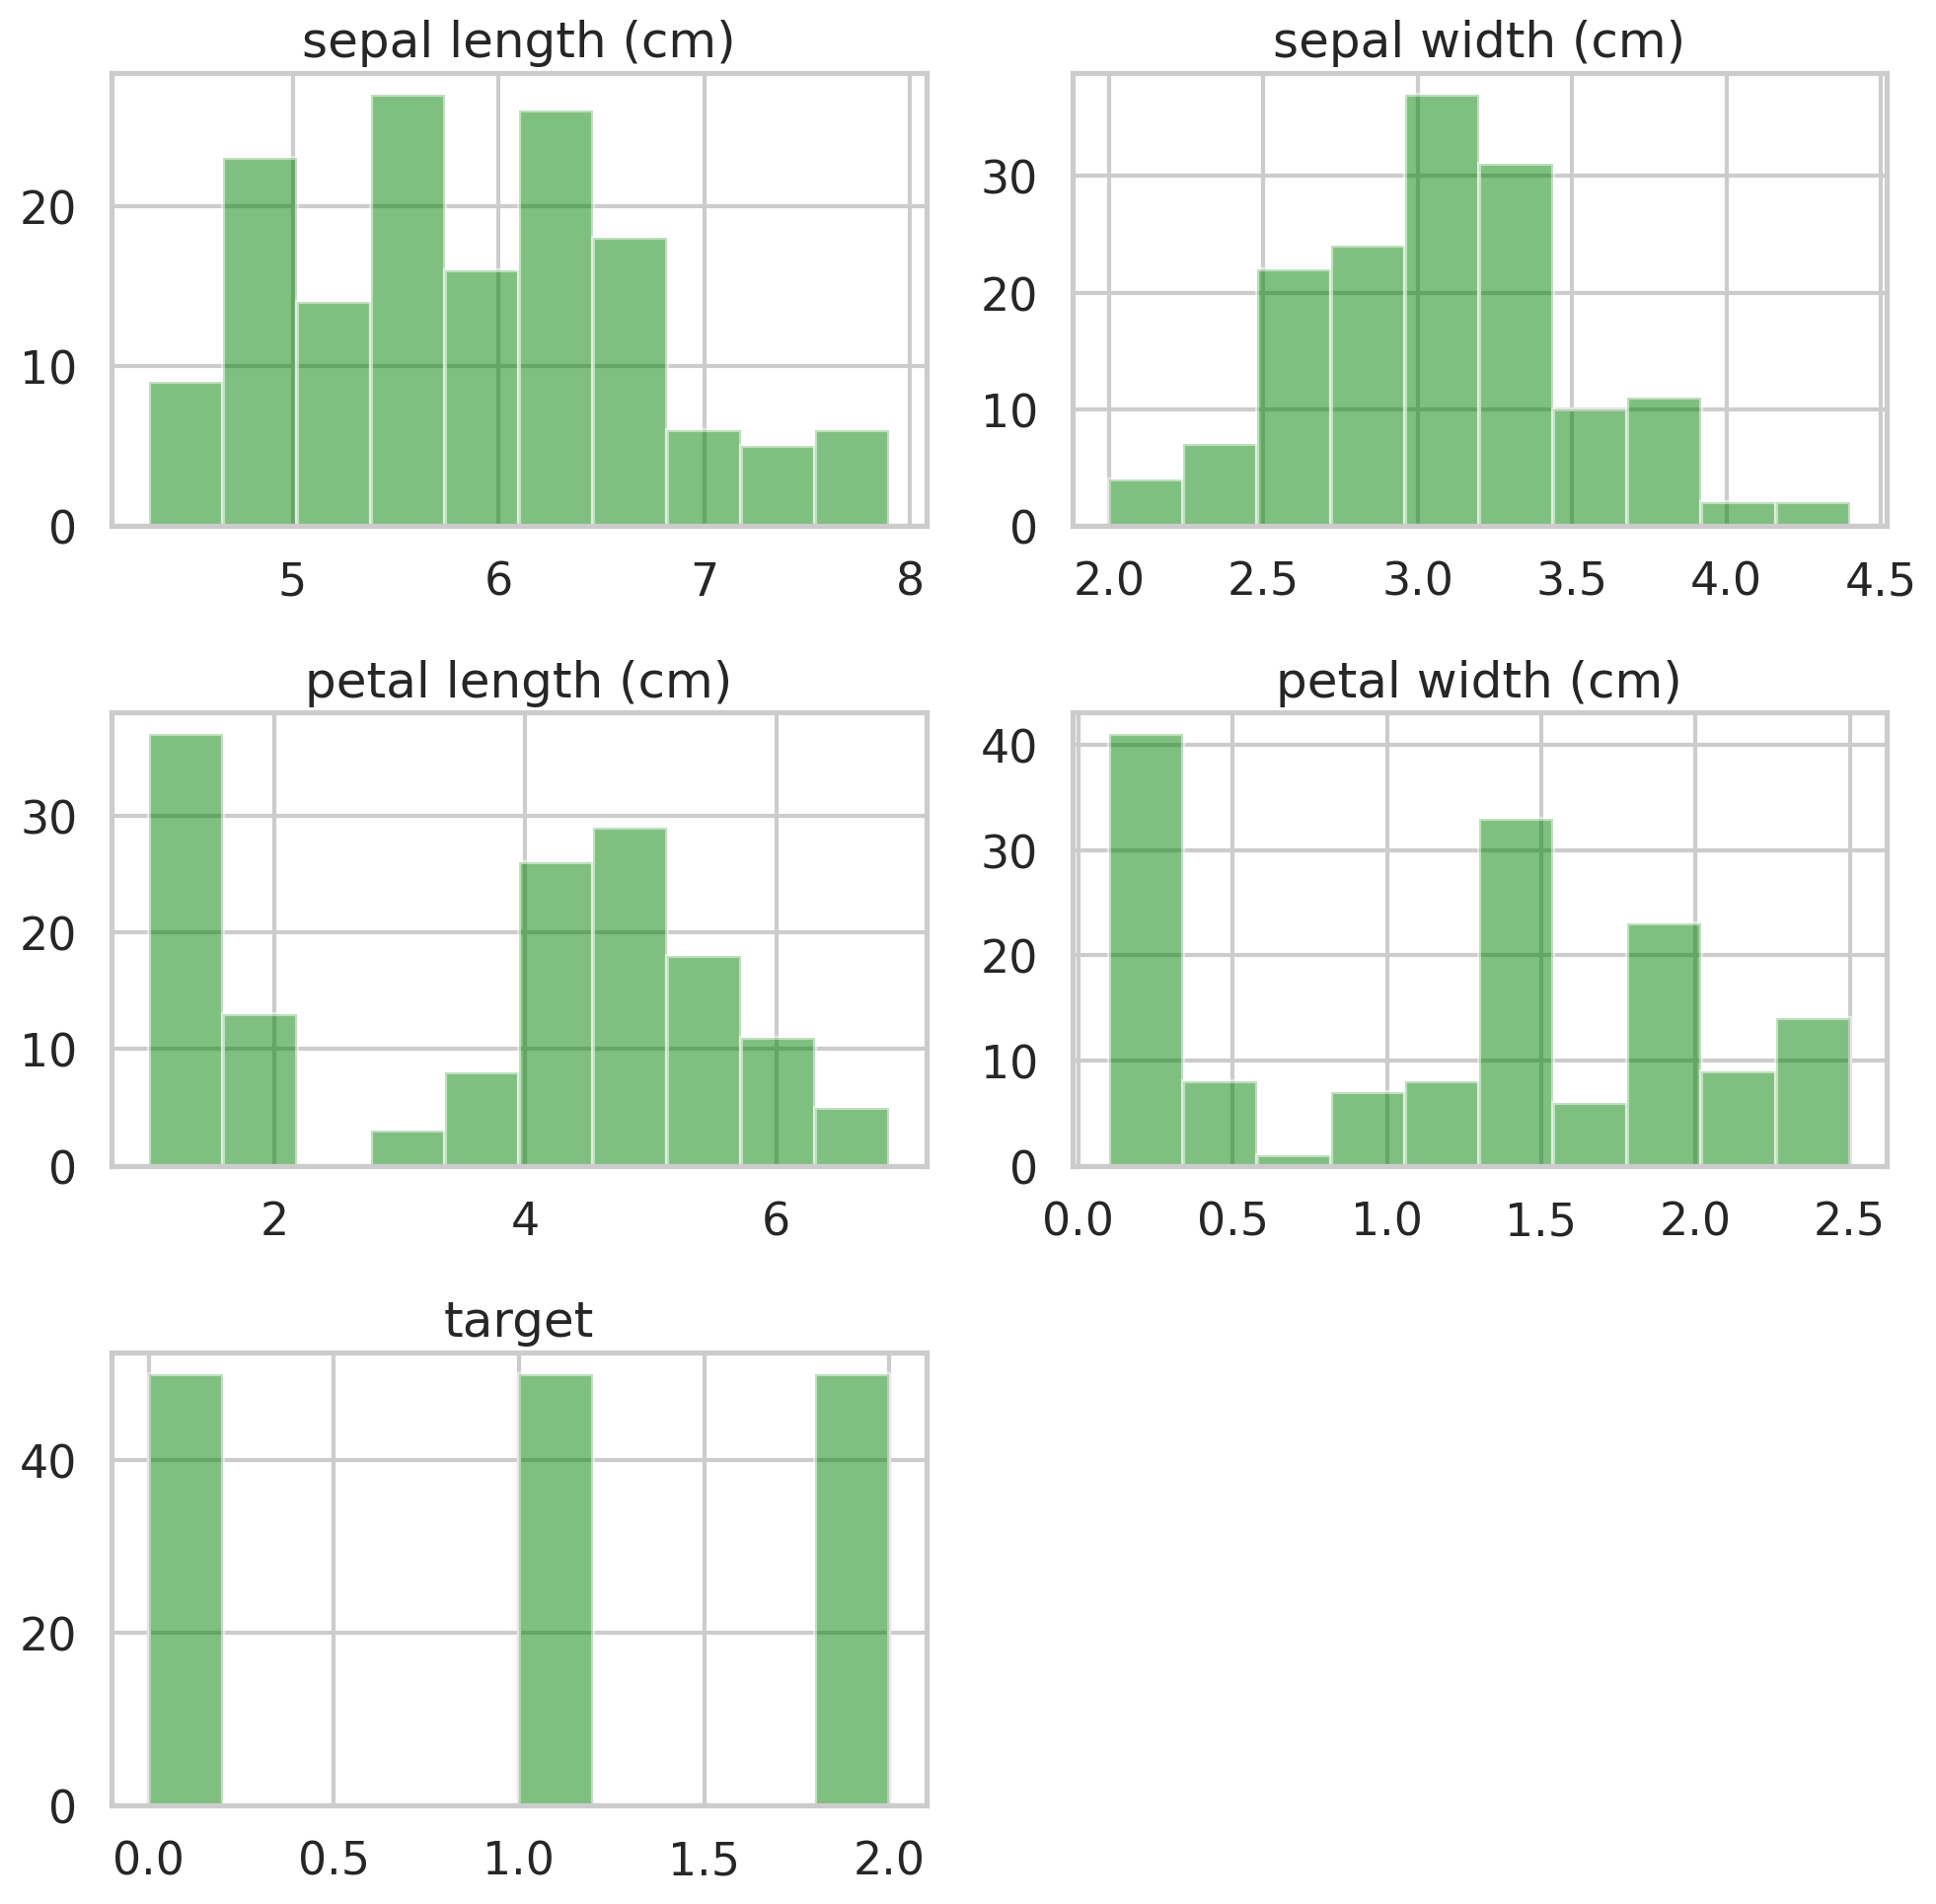

In [7]:
axes = df.hist(alpha=0.5, figsize=(10, 10), color='green')

plt.tight_layout()
plt.show()

In [9]:
import numpy as np
import random
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_iris

# Load the Iris dataset
iris_data = load_iris()

# Join features and labels into a single array
iris_dataset = np.column_stack((iris_data.data, iris_data.target.T))  # shape (150, 5)

# Shuffle the dataset (optional: for reproducibility)
random.seed(123)
random.shuffle(iris_dataset)

# Split features (X) and labels (y)
X = np.array([i[:4] for i in iris_dataset])  # shape (150, 4)
y = np.array([i[4] for i in iris_dataset])   # shape (150,)

# Use train_test_split to divide into 80% train, 20% test
train_X, test_X, train_y, test_y = train_test_split(
    X, y,
    test_size=0.2,
    random_state=11,  # set for reproducibility
    stratify=y        # keep label proportions balanced
)

# Now you have train_X, train_y, test_X, test_y ready

print(test_y)

[0. 0. 0. 1. 1. 0. 1. 0. 1. 0. 0. 1. 0. 0. 1. 0. 1. 0. 0. 2. 0. 0. 1. 0.
 0. 1. 0. 0. 0. 0.]


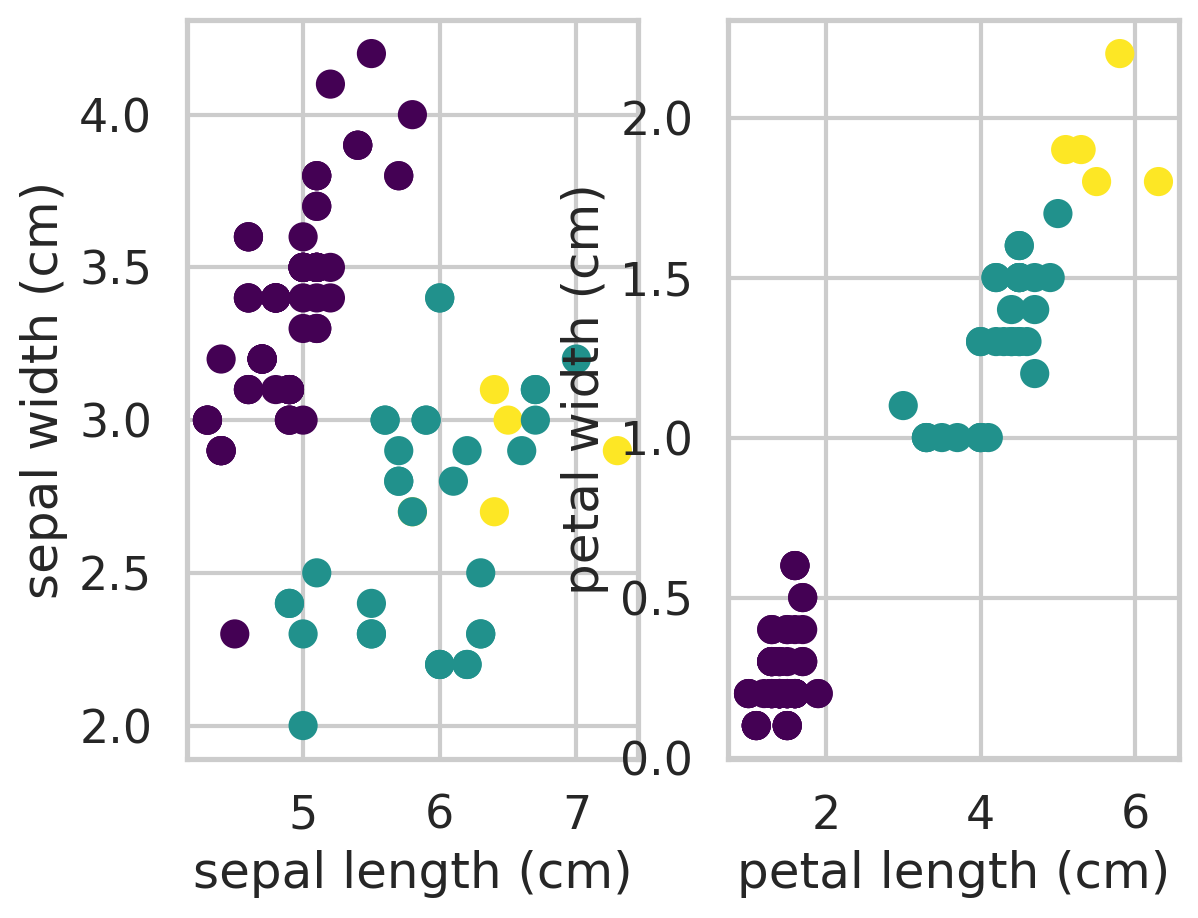

In [10]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# Plot training Samples

plt.subplot(1, 2, 1)
plt.scatter(train_X[:,0],train_X[:,1],c=train_y,cmap=cm.viridis)
plt.xlabel(iris_data.feature_names[0])
plt.ylabel(iris_data.feature_names[1])

plt.subplot(1, 2, 2)
plt.scatter(train_X[:,2],train_X[:,3],c=train_y,cmap=cm.viridis)
plt.xlabel(iris_data.feature_names[2])
plt.ylabel(iris_data.feature_names[3]);

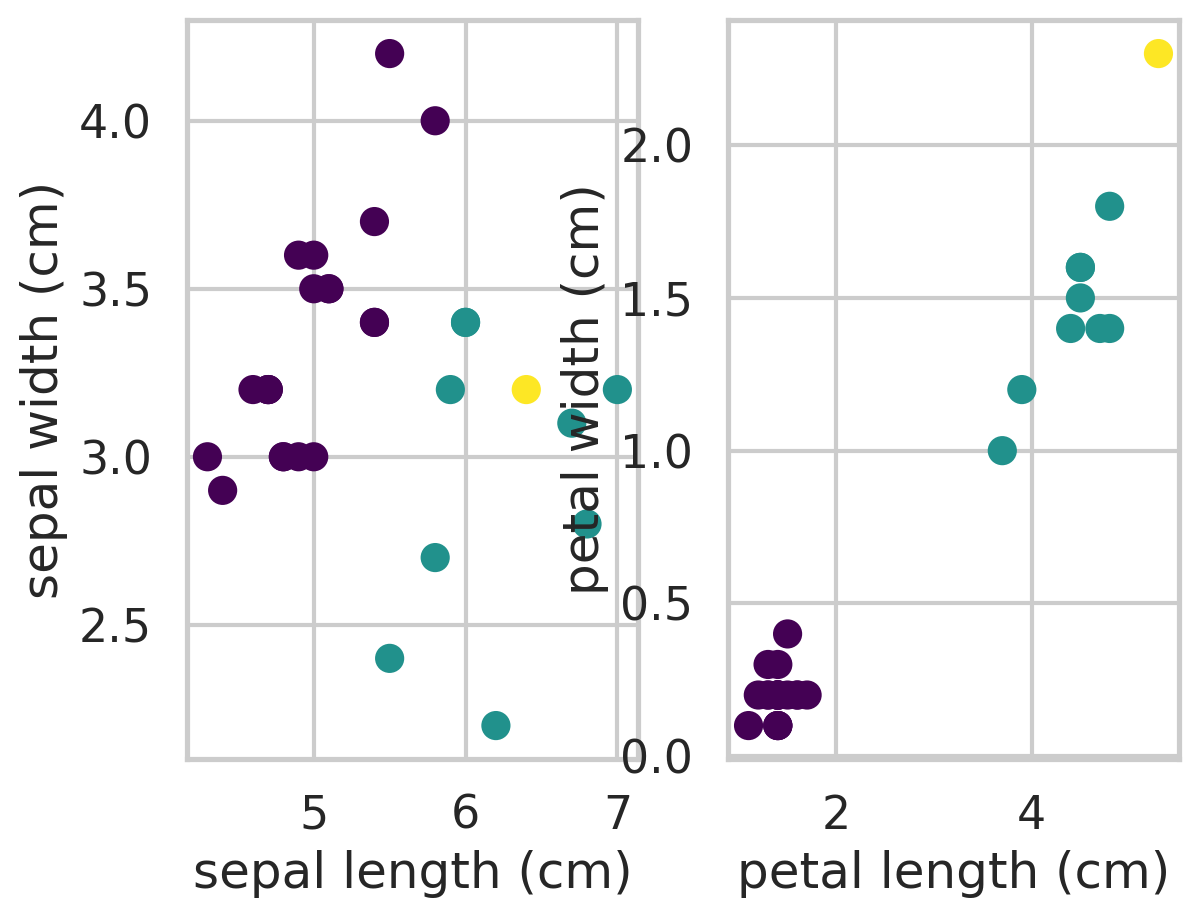

In [11]:
# Plot test samples
plt.subplot(1, 2, 1)
plt.scatter(test_X[:,0],test_X[:,1],c=test_y,cmap=cm.viridis)
plt.xlabel(iris_data.feature_names[0])
plt.ylabel(iris_data.feature_names[1])

plt.subplot(1, 2, 2)
plt.scatter(test_X[:,2],test_X[:,3],c=test_y,cmap=cm.viridis)
plt.xlabel(iris_data.feature_names[2])
plt.ylabel(iris_data.feature_names[3]);

In [12]:
# Imports necessários
from sklearn.base import BaseEstimator, ClassifierMixin
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# A classe foi modificada para incluir a lógica de Early Stopping no método .fit()

class MultiLayerPerceptron(BaseEstimator, ClassifierMixin):
    ativacao = {
        'sigmoid': (lambda x: 1/(1 + np.exp(-x))),
        'tanh': (lambda x: np.tanh(x)),
        'Relu': (lambda x: x*(x > 0)),
    }
    derivada = {
        'sigmoid': (lambda x: x*(1-x)),
        'tanh': (lambda x: 1-x**2),
        'Relu': (lambda x: 1 * (x>0))
    }

    def __init__(self, params=None):
        self.params = params
        if (params == None):
            self.inputLayer = 4
            self.hiddenLayer = 5
            self.outputLayer = 3
            self.learningRate = 0.005
            self.max_epochs = 600
            self.BiasHiddenValue = -1
            self.BiasOutputValue = -1
            self.activation = self.ativacao['sigmoid']
            self.deriv = self.derivada['sigmoid']
        else:
            self.inputLayer = params['InputLayer']
            self.hiddenLayer = params['HiddenLayer']
            self.outputLayer = params['OutputLayer']
            self.learningRate = params['LearningRate']
            self.max_epochs = params['Epocas']
            self.BiasHiddenValue = params['BiasHiddenValue']
            self.BiasOutputValue = params['BiasOutputValue']
            self.activation = self.ativacao[params['ActivationFunction']]
            self.deriv = self.derivada[params['ActivationFunction']]

        # Garante que a inicialização dos pesos seja reprodutível
        random.seed(42)
        np.random.seed(42)
        self.WEIGHT_hidden = self.starting_weights(self.inputLayer, self.hiddenLayer)
        self.WEIGHT_output = self.starting_weights(self.hiddenLayer, self.outputLayer)
        self.BIAS_hidden = np.array([self.BiasHiddenValue for i in range(self.hiddenLayer)])
        self.BIAS_output = np.array([self.BiasOutputValue for i in range(self.outputLayer)])
        self.classes_number = 3
        pass

    def starting_weights(self, rows, columns):
        return [[2 * random.random() - 1 for _ in range(columns)] for _ in range(rows)]

    def Backpropagation_Algorithm(self, x):
        ERROR_output = self.output - self.OUTPUT_L2
        DELTA_output = ((-1)*ERROR_output)

        for i in range(self.hiddenLayer):
            for j in range(self.outputLayer):
                self.WEIGHT_output[i][j] -= (self.learningRate * (DELTA_output[j] * self.OUTPUT_L1[i]))
        for j in range(self.outputLayer):
                self.BIAS_output[j] -= (self.learningRate * DELTA_output[j])

        delta_hidden = np.matmul(self.WEIGHT_output, DELTA_output) * self.deriv(self.OUTPUT_L1)

        for i in range(self.inputLayer):
            for j in range(self.hiddenLayer):
                self.WEIGHT_hidden[i][j] -= (self.learningRate * (delta_hidden[j] * x[i]))
        for j in range(self.hiddenLayer):
            self.BIAS_hidden[j] -= (self.learningRate * delta_hidden[j])

    def show_err_graphic(self, train_error_array, val_error_array, epoch_array):
        plt.figure(figsize=(12,6))
        
        # Array de épocas para o erro de treino
        epochs_to_plot_train = [e for e in epoch_array if e <= len(val_error_array)]

        plt.plot(epochs_to_plot_train, train_error_array, 'b-', marker='o', label='Erro de Treino')

        # Array de épocas para o erro de validação
        val_epochs = range(1, len(val_error_array) + 1)
        plt.plot(val_epochs, val_error_array, 'r-', marker='.', markersize=4, linestyle='--', label='Erro de Validação')
        
        # Linha vertical para indicar onde o treinamento parou
        plt.axvline(x=len(val_error_array), color='k', linestyle=':', label=f'Parada Antecipada na Época {len(val_error_array)}')

        plt.xlabel("Número de Épocas")
        plt.ylabel("Erro Quadrático (MSE)")
        plt.title("Minimização do Erro (Treino vs. Validação)")
        plt.legend()
        plt.grid(True)
        plt.xlim(0, len(val_error_array) + 50) # Ajusta o limite do gráfico
        plt.show()


    def fit(self, X, y, X_val, y_val):
        patience = 100
        patience_counter = 0
        best_val_error = float('inf')

        best_WEIGHT_hidden = self.WEIGHT_hidden.copy()
        best_WEIGHT_output = self.WEIGHT_output.copy()
        best_BIAS_hidden = self.BIAS_hidden.copy()
        best_BIAS_output = self.BIAS_output.copy()
        
        count_epoch = 1
        n = len(X)
        epoch_array = []
        train_error_array = []
        val_error_array = []

        while(count_epoch <= self.max_epochs):
            total_error = 0
            
            for idx, inputs in enumerate(X):
                self.output = np.zeros(self.classes_number)
                self.OUTPUT_L1 = self.activation((np.dot(inputs, self.WEIGHT_hidden) + self.BIAS_hidden))
                self.OUTPUT_L2 = (np.dot(self.OUTPUT_L1, self.WEIGHT_output) + self.BIAS_output)

                if(y[idx] == 0): self.output = np.array([1,0,0])
                elif(y[idx] == 1): self.output = np.array([0,1,0])
                elif(y[idx] == 2): self.output = np.array([0,0,1])

                square_error = 0
                for i in range(self.outputLayer):
                    erro = (self.output[i] - self.OUTPUT_L2[i])**2
                    square_error += (0.5 * erro)
                total_error += square_error
                self.Backpropagation_Algorithm(inputs)
            
            val_hidden_output = self.activation(np.matmul(X_val, self.WEIGHT_hidden) + self.BIAS_hidden)
            val_scores = np.matmul(val_hidden_output, self.WEIGHT_output) + self.BIAS_output
            
            y_val_one_hot = np.zeros((len(y_val), self.outputLayer))
            for i, label in enumerate(y_val):
                y_val_one_hot[i, label] = 1

            val_error = np.mean(0.5 * (y_val_one_hot - val_scores)**2)
            val_error_array.append(val_error)
            
            if val_error < best_val_error:
                best_val_error = val_error
                patience_counter = 0
                best_WEIGHT_hidden = [w.copy() for w in self.WEIGHT_hidden]
                best_WEIGHT_output = [w.copy() for w in self.WEIGHT_output]
                best_BIAS_hidden = self.BIAS_hidden.copy()
                best_BIAS_output = self.BIAS_output.copy()
            else:
                patience_counter += 1

            if patience_counter >= patience:
                print(f"--- PARADA ANTECIPADA NA ÉPOCA {count_epoch}! ---")
                print(f"Melhor erro de validação: {best_val_error:.6f}")
                break
            
            mean_epoch_error = total_error / n
            if((count_epoch % 50 == 0)or(count_epoch == 1)):
                print(f"Época {count_epoch} - Erro Treino: {mean_epoch_error:.6f} - Erro Validação: {val_error:.6f}")
                train_error_array.append(mean_epoch_error)
                epoch_array.append(count_epoch)

            count_epoch += 1
        
        print("\nRestaurando os melhores pesos encontrados durante o treinamento.")
        self.WEIGHT_hidden = best_WEIGHT_hidden
        self.WEIGHT_output = best_WEIGHT_output
        self.BIAS_hidden = best_BIAS_hidden
        self.BIAS_output = best_BIAS_output

        self.show_err_graphic(train_error_array, val_error_array, epoch_array)
        return self

    def predict(self, X, y=None):
        my_predictions = []
        hidden_output = self.activation(np.matmul(X, self.WEIGHT_hidden) + self.BIAS_hidden)
        scores = np.matmul(hidden_output, self.WEIGHT_output) + self.BIAS_output

        for i in scores:
            my_predictions.append(max(enumerate(i), key=lambda x:x[1])[0])

        if y is not None:
            array_score = []
            for i in range(len(my_predictions)):
                if my_predictions[i] == 0: array_score.append([i, 'Iris-setosa', my_predictions[i], y[i]])
                elif my_predictions[i] == 1: array_score.append([i, 'Iris-versicolour', my_predictions[i], y[i]])
                elif my_predictions[i] == 2: array_score.append([i, 'Iris-virginica', my_predictions[i], y[i]])
            dataframe = pd.DataFrame(array_score, columns=['_id', 'class', 'output', 'hoped_output'])
            return my_predictions, dataframe
        else:
            return my_predictions

In [13]:
# Carregando o dataset Iris
df = pd.read_csv('https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data', header=None)

# Mapeando as classes para números
df[4] = df[4].map({
    'Iris-setosa':0,
    'Iris-versicolor':1,
    'Iris-virginica':2
})

# Separando features (X) e labels (y)
X = df.iloc[:,:-1].values
y = df.iloc[:,-1].values

# --- NOVO: DIVISÃO EM TREINO, VALIDAÇÃO E TESTE ---
# Primeiro, separamos um conjunto de teste (20% do total) para a avaliação final.
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Agora, pegamos os 80% restantes e dividimos em treino e validação.
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.25, random_state=42, stratify=y_train_val) # 0.25 * 0.8 = 0.2

print(f"Total de amostras: {len(X)}")
print(f"Amostras de Treino: {len(X_train)}")
print(f"Amostras de Validação: {len(X_val)}")
print(f"Amostras de Teste: {len(X_test)}")

Total de amostras: 150
Amostras de Treino: 90
Amostras de Validação: 30
Amostras de Teste: 30


Época 1 - Erro Treino: 0.461885 - Erro Validação: 0.130270
Época 50 - Erro Treino: 0.172305 - Erro Validação: 0.057489
Época 100 - Erro Treino: 0.170674 - Erro Validação: 0.056843
Época 150 - Erro Treino: 0.170245 - Erro Validação: 0.056743
Época 200 - Erro Treino: 0.170040 - Erro Validação: 0.056713
Época 250 - Erro Treino: 0.169901 - Erro Validação: 0.056687
Época 300 - Erro Treino: 0.169784 - Erro Validação: 0.056654
Época 350 - Erro Treino: 0.169674 - Erro Validação: 0.056613
Época 400 - Erro Treino: 0.169564 - Erro Validação: 0.056563
Época 450 - Erro Treino: 0.169451 - Erro Validação: 0.056506
Época 500 - Erro Treino: 0.169333 - Erro Validação: 0.056441
Época 550 - Erro Treino: 0.169208 - Erro Validação: 0.056371
Época 600 - Erro Treino: 0.169075 - Erro Validação: 0.056295
Época 650 - Erro Treino: 0.168934 - Erro Validação: 0.056216
Época 700 - Erro Treino: 0.168781 - Erro Validação: 0.056133
Época 750 - Erro Treino: 0.168602 - Erro Validação: 0.056040
Época 800 - Erro Treino: 0.

/tmp/ipykernel_8135/1608984926.py:86: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "r-" (-> linestyle='-'). The keyword argument will take precedence.
  plt.plot(val_epochs, val_error_array, 'r-', marker='.', markersize=4, linestyle='--', label='Erro de Validação')


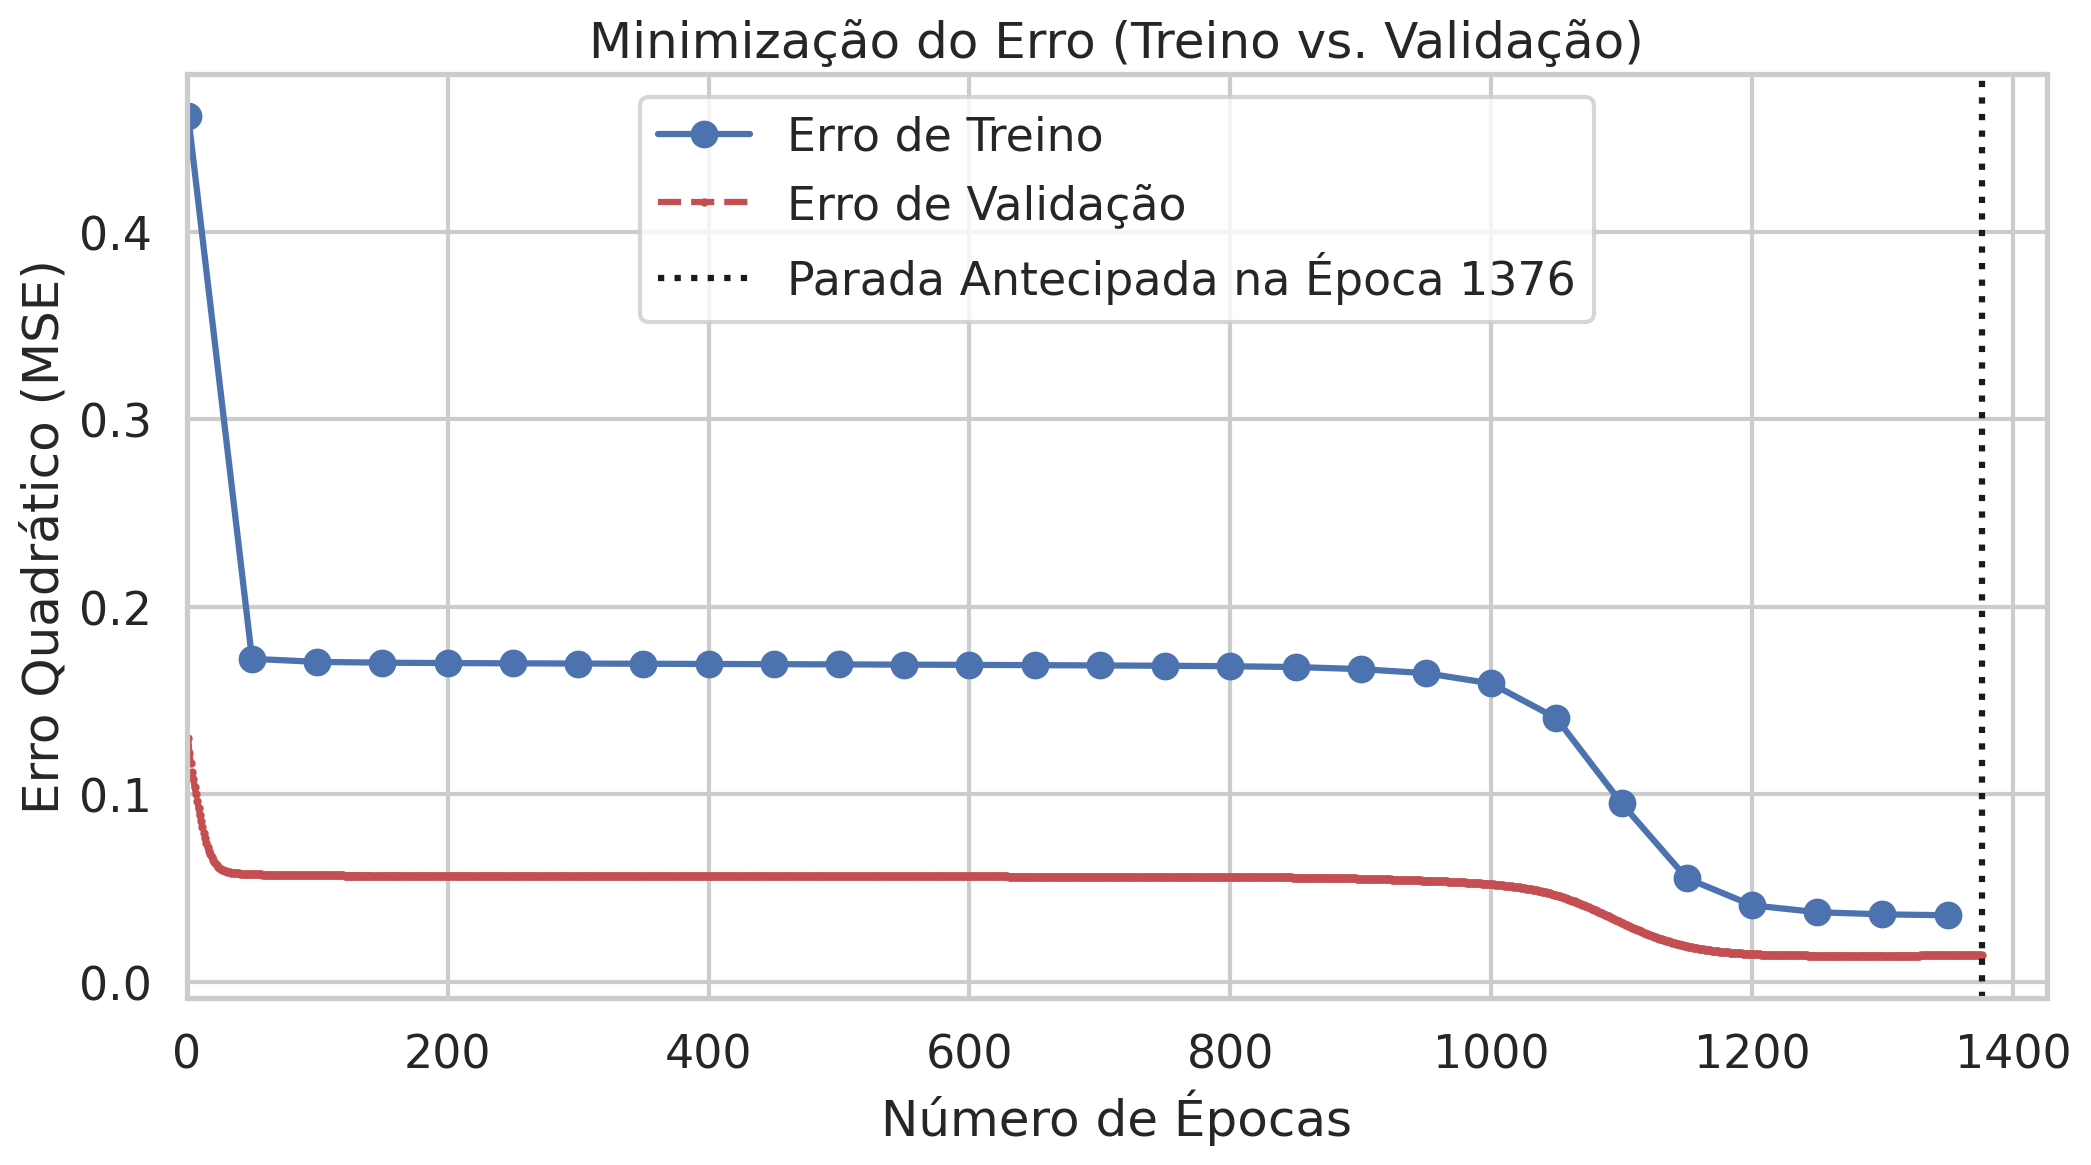

MultiLayerPerceptron(params={'ActivationFunction': 'sigmoid',
                             'BiasHiddenValue': -1, 'BiasOutputValue': -1,
                             'Epocas': 3000, 'HiddenLayer': 5, 'InputLayer': 4,
                             'LearningRate': 0.005, 'OutputLayer': 3})

In [14]:
dictionary = {'InputLayer':4, 'HiddenLayer':5, 'OutputLayer':3,
              'Epocas':3000, 'LearningRate':0.005,'BiasHiddenValue':-1,
              'BiasOutputValue':-1, 'ActivationFunction':'sigmoid'}

Perceptron = MultiLayerPerceptron(dictionary)
# A chamada ao fit agora inclui os dados de validação
Perceptron.fit(X_train, y_train, X_val, y_val)

In [15]:
# Avaliação final no conjunto de teste, que o modelo nunca viu
print("--- AVALIAÇÃO FINAL NO CONJUNTO DE TESTE ---")
test_predictions, dataframe = Perceptron.predict(X_test, y_test)

accuracy = accuracy_score(y_test, test_predictions)

print(f"\nAcurácia no conjunto de teste: {accuracy * 100:.2f}%")
print("\nDataFrame de Predições vs. Real:")
print(dataframe)

--- AVALIAÇÃO FINAL NO CONJUNTO DE TESTE ---

Acurácia no conjunto de teste: 96.67%

DataFrame de Predições vs. Real:
    _id             class  output  hoped_output
0     0       Iris-setosa       0             0
1     1    Iris-virginica       2             2
2     2  Iris-versicolour       1             1
3     3  Iris-versicolour       1             1
4     4       Iris-setosa       0             0
5     5  Iris-versicolour       1             1
6     6       Iris-setosa       0             0
7     7       Iris-setosa       0             0
8     8    Iris-virginica       2             2
9     9    Iris-virginica       2             1
10   10    Iris-virginica       2             2
11   11    Iris-virginica       2             2
12   12    Iris-virginica       2             2
13   13  Iris-versicolour       1             1
14   14       Iris-setosa       0             0
15   15       Iris-setosa       0             0
16   16       Iris-setosa       0             0
17   17  Iris-vers

In [16]:
prev, dataframe = Perceptron.predict(test_X, test_y)
hits = n_set = n_vers = n_virg = 0
score_set = score_vers = score_virg = 0
for j in range(len(test_y)):
    if(test_y[j] == 0): n_set += 1
    elif(test_y[j] == 1): n_vers += 1
    elif(test_y[j] == 2): n_virg += 1

for i in range(len(test_y)):
    if test_y[i] == prev[i]:
        hits += 1
    if test_y[i] == prev[i] and test_y[i] == 0:
        score_set += 1
    elif test_y[i] == prev[i] and test_y[i] == 1:
        score_vers += 1
    elif test_y[i] == prev[i] and test_y[i] == 2:
        score_virg += 1

hits = (hits / len(test_y)) * 100
faults = 100 - hits

print("Porcents :","%.2f"%(hits),"% hits","and","%.2f"%(faults),"% faults")
print("Total samples of test",len(test_y))
print("*Iris-Setosa:",n_set,"samples", score_set, "hits")
print("*Iris-Versicolour:",n_vers,"samples", score_vers, "hits")
print("*Iris-Virginica:",n_virg,"samples", score_virg, "hits")

Porcents : 96.67 % hits and 3.33 % faults
Total samples of test 30
*Iris-Setosa: 20 samples 20 hits
*Iris-Versicolour: 9 samples 8 hits
*Iris-Virginica: 1 samples 1 hits


In [17]:
dataframe

,_id,class,output,hoped_output
0,0,Iris-setosa,0,0.0
1,1,Iris-setosa,0,0.0
2,2,Iris-setosa,0,0.0
3,3,Iris-versicolour,1,1.0
4,4,Iris-versicolour,1,1.0
5,5,Iris-setosa,0,0.0
6,6,Iris-versicolour,1,1.0
7,7,Iris-setosa,0,0.0
8,8,Iris-versicolour,1,1.0
9,9,Iris-setosa,0,0.0


- Acurracy Iris-Setosa: 100.00 %
- Acurracy Iris-Versicolour: 88.89 %
- Acurracy Iris-Virginica: 100.00 %


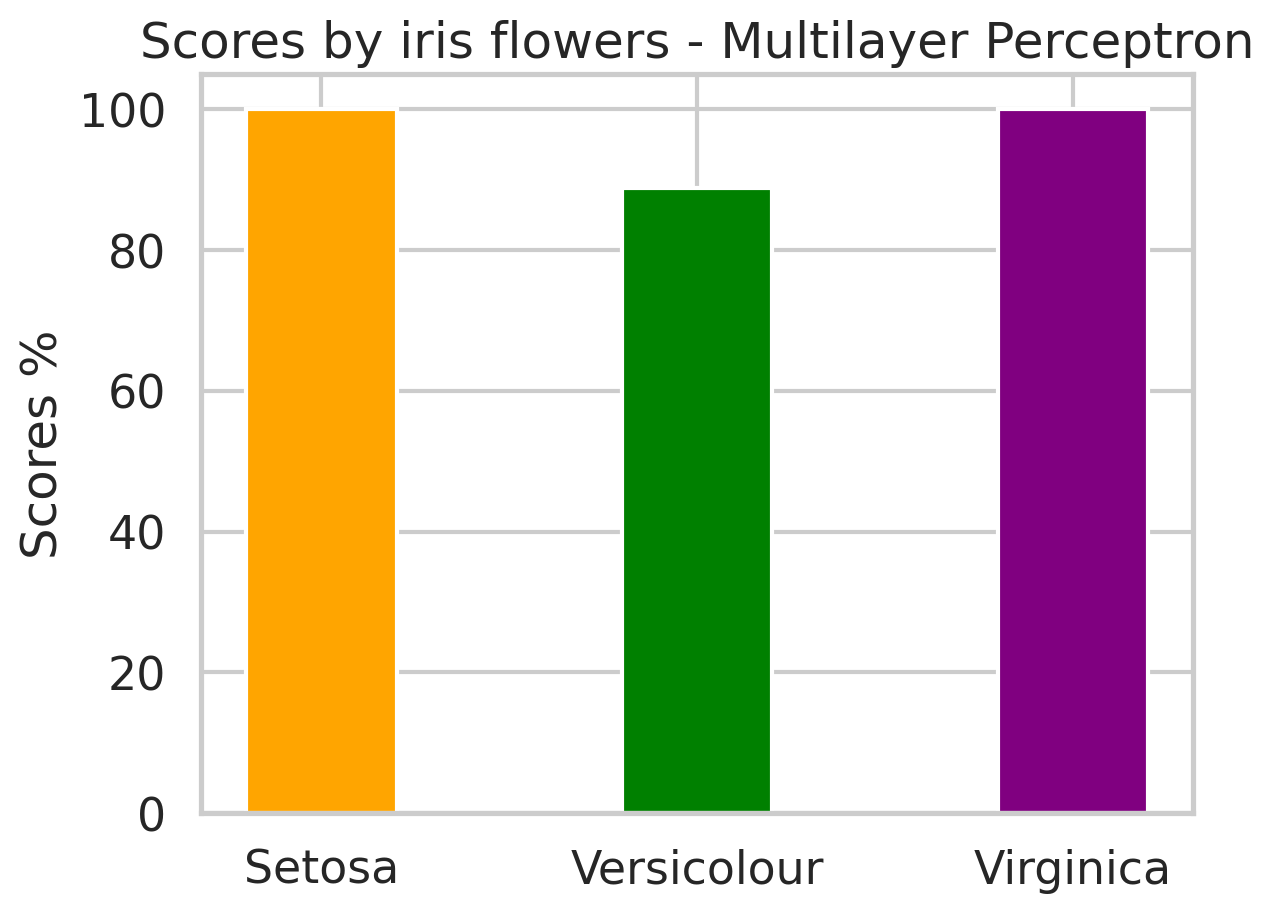

In [18]:
acc_set = (score_set/n_set)*100
acc_vers = (score_vers/n_vers)*100
acc_virg = (score_virg/n_virg)*100
print("- Acurracy Iris-Setosa:","%.2f"%acc_set, "%")
print("- Acurracy Iris-Versicolour:","%.2f"%acc_vers, "%")
print("- Acurracy Iris-Virginica:","%.2f"%acc_virg, "%")
names = ["Setosa","Versicolour","Virginica"]
x1 = [2.0,4.0,6.0]
fig, ax = plt.subplots()
r1 = plt.bar(x1[0], acc_set,color='orange',label='Iris-Setosa')
r2 = plt.bar(x1[1], acc_vers,color='green',label='Iris-Versicolour')
r3 = plt.bar(x1[2], acc_virg,color='purple',label='Iris-Virginica')
plt.ylabel('Scores %')
plt.xticks(x1, names);plt.title('Scores by iris flowers - Multilayer Perceptron')
plt.show()